# 06 · Evaluación final, equidad, interpretabilidad y herramienta (Fases 6, 7 y 8)

- **Fase 6:** el modelo elegido en el notebook 05 se evalúa **una sola vez** en julio (test).
- **Fase 7:** ¿qué aprendió el modelo? Importancia de variables, dependencia parcial y coeficientes.
- **Fase 8:** se entrena el modelo de producción, se guarda, se genera un ejemplo de la lista diaria y se simula el monitoreo en agosto–septiembre.

> ⚠️ **Regla:** después de ver el resultado en test **no se vuelve a ajustar el modelo**. Si se ajustara, julio dejaría de ser una evaluación honesta.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import funciones_inasistencia as fi
import funciones_modelado as fm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
fm.estilo_graficos()

import json
from pathlib import Path
import joblib
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

dataset = pd.read_parquet("dataset_modelo_v2.parquet").sort_values("fecha_cita").reset_index(drop=True)
config = json.load(open("modelos/config_modelo_final.json", encoding="utf-8"))
negocio = json.load(open("modelos/config_negocio.json", encoding="utf-8"))
mejores_parametros = json.load(open("modelos/mejores_parametros.json", encoding="utf-8"))
metadatos = json.load(open("modelos/metadatos_dataset.json", encoding="utf-8"))

variables = config["variables"]
nombre_modelo, parametros = config["modelo"], config["parametros"]
categoricas, numericas = fm.separar_tipos(dataset[variables])
print(f"Modelo: {config['nombre']} | calibrar: {config['calibrar']}")
print("Parámetros:", parametros)

Modelo: 4. LightGBM | calibrar: False
Parámetros: {'colsample_bytree': 0.7117007403531848, 'learning_rate': 0.04431752678446183, 'min_child_samples': 155, 'n_estimators': 621, 'num_leaves': 25, 'reg_lambda': 0.006242659053860567, 'subsample': 0.88453678109946, 'subsample_freq': 1}


In [2]:
def entrenar(datos_entrenamiento, datos_calibracion=None):
    # Entrena el modelo elegido. Si config['calibrar'], calibra con un periodo POSTERIOR (temporal)
    modelo = fm.crear_modelo(nombre_modelo, categoricas, numericas, **parametros)
    modelo.fit(datos_entrenamiento[variables], datos_entrenamiento["no_asiste"], **fm.parametros_fit(nombre_modelo, categoricas))
    if config["calibrar"] and datos_calibracion is not None:
        modelo = CalibratedClassifierCV(FrozenEstimator(modelo), method="isotonic")
        modelo.fit(datos_calibracion[variables], datos_calibracion["no_asiste"])
    return modelo

train = dataset[dataset["particion"] == "train"]
validacion = dataset[dataset["particion"] == "validacion"]
desarrollo = dataset[dataset["particion"].isin(["train", "validacion"])]
test = dataset[dataset["particion"] == "test"]

## 6.1 Evaluación única en test (julio)
Entrenamos con enero–junio (o enero–mayo + calibración con junio, si el notebook 05 decidió calibrar) y predecimos julio.

In [3]:
if config["calibrar"]:
    modelo_test = entrenar(train, validacion)
else:
    modelo_test = entrenar(desarrollo)

p_test = modelo_test.predict_proba(test[variables])[:, 1]
y_test, fechas_test = test["no_asiste"], test["fecha_cita"]
metricas_test = fm.metricas(y_test, p_test, fechas_test)

comparacion = pd.DataFrame({
    "Validación cruzada (ene-jun)": pd.Series(config["metricas_cv"]),
    "TEST (julio)": pd.Series(metricas_test),
})
comparacion["diferencia"] = comparacion["TEST (julio)"] - comparacion["Validación cruzada (ene-jun)"]
comparacion.round(4)

,Validación cruzada (ene-jun),TEST (julio),diferencia
AUC,0.6788,0.6816,0.0029
PR_AUC,0.5165,0.4900,-0.0265
Brier,0.2013,0.1958,-0.0055
Precision@10%,0.6230,0.5753,-0.0477
Recall@10%,0.1880,0.1837,-0.0043
Especificidad@10%,0.9438,0.9384,-0.0054
F1@10%,0.2888,0.2784,-0.0103
Precision@30%,0.5048,0.4850,-0.0198
Recall@30%,0.4577,0.4653,0.0076
Especificidad@30%,0.7782,0.7756,-0.0026


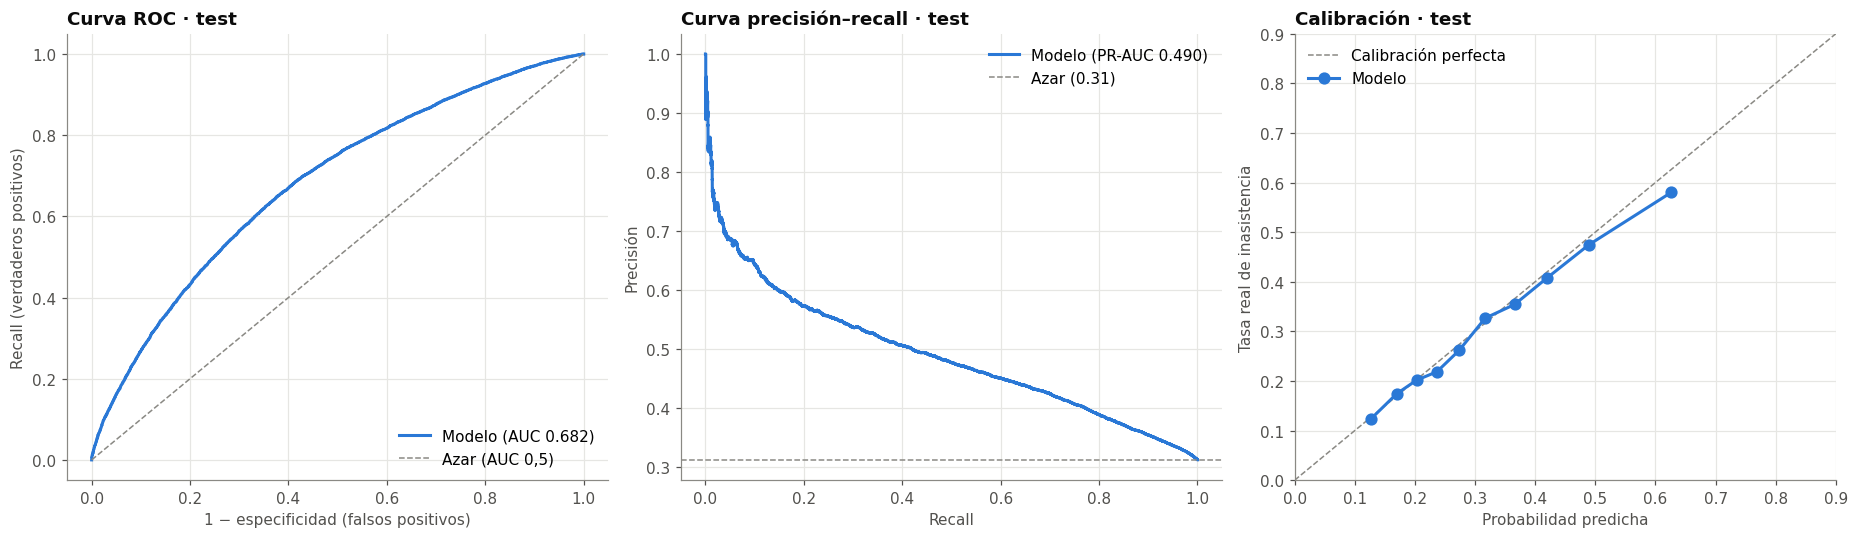

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, color=fm.AZUL, linewidth=2, label=f"Modelo (AUC {metricas_test['AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], color=fm.GRIS, linestyle="--", linewidth=1, label="Azar (AUC 0,5)")
axes[0].set_xlabel("1 − especificidad (falsos positivos)")
axes[0].set_ylabel("Recall (verdaderos positivos)")
axes[0].set_title("Curva ROC · test")
axes[0].legend(loc="lower right")

precision, recall, _ = precision_recall_curve(y_test, p_test)
axes[1].plot(recall, precision, color=fm.AZUL, linewidth=2, label=f"Modelo (PR-AUC {metricas_test['PR_AUC']:.3f})")
axes[1].axhline(y_test.mean(), color=fm.GRIS, linestyle="--", linewidth=1, label=f"Azar ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva precisión–recall · test")
axes[1].legend(loc="upper right")

real, predicho = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
axes[2].plot([0, 1], [0, 1], color=fm.GRIS, linestyle="--", linewidth=1, label="Calibración perfecta")
axes[2].plot(predicho, real, color=fm.AZUL, marker="o", markersize=7, linewidth=2, label="Modelo")
axes[2].set_xlim(0, 0.9)
axes[2].set_ylim(0, 0.9)
axes[2].set_xlabel("Probabilidad predicha")
axes[2].set_ylabel("Tasa real de inasistencia")
axes[2].set_title("Calibración · test")
axes[2].legend(loc="upper left")
plt.tight_layout()
plt.show()

In [5]:
# Matriz de confusión en los dos escenarios de capacidad
for capacidad in [0.10, 0.30]:
    marcado = fm.marcar_top_por_dia(p_test, fechas_test, capacidad)
    vp, fp, fn, vn = fm.matriz_confusion(y_test, marcado)
    matriz = pd.DataFrame([[vp, fn], [fp, vn]], index=["Real: NO asistió", "Real: asistió"],
                          columns=[f"Llamado (top {capacidad:.0%})", "No llamado"])
    print(f"\nCapacidad {capacidad:.0%}:")
    display(matriz)


Capacidad 10%:


,Llamado (top 10%),No llamado
Real: NO asistió,2361,10494
Real: asistió,1743,26550



Capacidad 30%:


,Llamado (top 30%),No llamado
Real: NO asistió,5981,6874
Real: asistió,6350,21943


## 6.2 Lift y ganancia acumulada
**Ganancia acumulada:** si llamo al X % de mayor riesgo de cada día, ¿qué % de todas las inasistencias capturo? **Lift:** cuántas veces mejor es eso que llamar al azar.

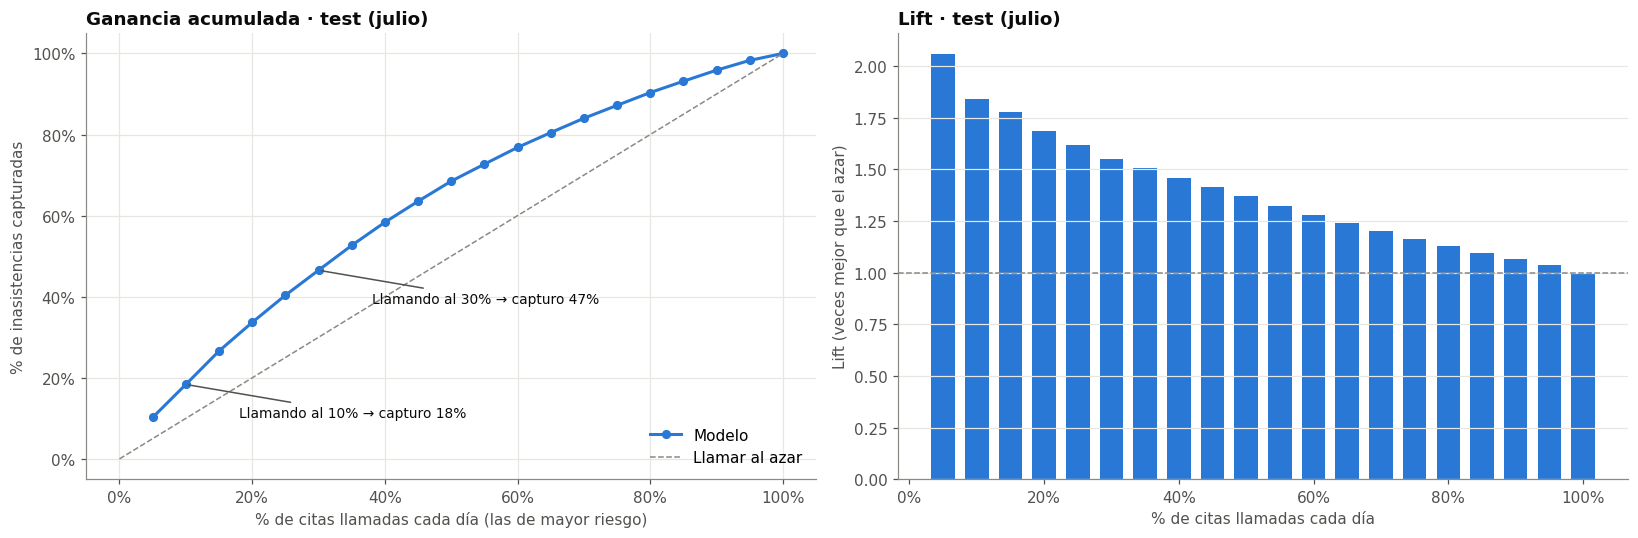

,capacidad,recall,precision,lift,beneficio_neto_mes_COP
0,0.05,0.102,0.643,2.057,9670000.0
1,0.10,0.184,0.575,1.841,16301250.0
3,0.20,0.337,0.526,1.685,28128750.0
5,0.30,0.465,0.485,1.553,36458750.0
9,0.50,0.685,0.428,1.370,47636250.0


In [6]:
capacidades = np.arange(0.05, 1.01, 0.05)
filas = []
for c in capacidades:
    marcado = fm.marcar_top_por_dia(p_test, fechas_test, c)
    vp, fp, fn, vn = fm.matriz_confusion(y_test, marcado)
    llamadas = vp + fp
    beneficio = (vp * negocio["EFECTIVIDAD_LLAMADA"] * negocio["COSTO_CUPO_PERDIDO"] - llamadas * negocio["COSTO_LLAMADA"])
    filas.append({"capacidad": c, "recall": vp / (vp + fn), "precision": vp / llamadas, "lift": (vp / llamadas) / y_test.mean(),
                  "beneficio_neto_mes_COP": beneficio})
ganancia = pd.DataFrame(filas)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(ganancia["capacidad"], ganancia["recall"], color=fm.AZUL, linewidth=2, marker="o", markersize=5, label="Modelo")
axes[0].plot([0, 1], [0, 1], color=fm.GRIS, linestyle="--", linewidth=1, label="Llamar al azar")
for c in [0.10, 0.30]:
    fila = ganancia.loc[(ganancia["capacidad"] - c).abs().idxmin()]
    axes[0].annotate(f"Llamando al {c:.0%} → capturo {fila['recall']:.0%}", (fila["capacidad"], fila["recall"]),
                     xytext=(fila["capacidad"] + 0.08, fila["recall"] - 0.08), fontsize=9, color=fm.TINTA,
                     arrowprops={"arrowstyle": "-", "color": fm.TINTA_SUAVE})
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_xlabel("% de citas llamadas cada día (las de mayor riesgo)")
axes[0].set_ylabel("% de inasistencias capturadas")
axes[0].set_title("Ganancia acumulada · test (julio)")
axes[0].legend(loc="lower right")

axes[1].bar(ganancia["capacidad"], ganancia["lift"], width=0.035, color=fm.AZUL)
axes[1].axhline(1, color=fm.GRIS, linestyle="--", linewidth=1)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set_xlabel("% de citas llamadas cada día")
axes[1].set_ylabel("Lift (veces mejor que el azar)")
axes[1].set_title("Lift · test (julio)")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

ganancia[ganancia["capacidad"].round(2).isin([0.05, 0.10, 0.20, 0.30, 0.50])].round(3)

> El **beneficio neto** usa los supuestos de costo de `config_negocio.json` (ver notebook 04) y corresponde al mes de julio. Es un orden de magnitud para discutir con la IPS, no un valor contable.

## 6.3 Desempeño por subgrupo (equidad)
Revisamos que ningún grupo quede mal servido. Para cada grupo miramos:
- **AUC dentro del grupo:** ¿el modelo ordena bien a sus pacientes?
- **Calibración:** probabilidad promedio predicha vs. tasa real. Una brecha grande significa que el modelo **sobre** o **subestima** el riesgo de ese grupo.
- **% del grupo marcado en el top 10 %:** ¿algún grupo recibe muchas más llamadas? Eso está bien si su riesgo real es mayor, pero debe ser proporcional.

In [7]:
evaluacion = test.assign(p=p_test, marcado=fm.marcar_top_por_dia(p_test, fechas_test, 0.10))

def tabla_subgrupo(variable):
    filas = []
    for grupo, datos in evaluacion.groupby(variable):
        if len(datos) < 300 or datos["no_asiste"].nunique() < 2:
            continue
        filas.append({"variable": variable, "grupo": grupo, "citas": len(datos),
                      "tasa_real": datos["no_asiste"].mean(), "prob_predicha": datos["p"].mean(),
                      "brecha_calibracion": datos["p"].mean() - datos["no_asiste"].mean(),
                      "AUC": roc_auc_score(datos["no_asiste"], datos["p"]),
                      "%_marcado_top10": datos["marcado"].mean(),
                      "precision_top10": datos.loc[datos["marcado"] == 1, "no_asiste"].mean()})
    return pd.DataFrame(filas)

subgrupos = pd.concat([tabla_subgrupo(v) for v in ["sede", "regimen", "sexo", "grupo_edad", "familia_servicio"]], ignore_index=True)
auc_global = metricas_test["AUC"]
subgrupos["alerta"] = np.where((subgrupos["AUC"] < auc_global - 0.05) | (subgrupos["brecha_calibracion"].abs() > 0.05), "⚠️ revisar", "")
subgrupos.round(3)

,variable,grupo,citas,tasa_real,prob_predicha,brecha_calibracion,AUC,%_marcado_top10,precision_top10,alerta
0,sede,ARMENIA,5068,0.339,0.362,0.023,0.682,0.143,0.574,
1,sede,CENTRO,18865,0.305,0.317,0.012,0.682,0.091,0.563,
2,sede,LAURELES,13326,0.300,0.311,0.010,0.679,0.090,0.578,
3,sede,VILLAMARIA,3889,0.354,0.341,-0.013,0.677,0.116,0.616,
4,regimen,Contributivo,40107,0.310,0.321,0.010,0.681,0.097,0.574,
5,regimen,Subsidiado,1041,0.392,0.404,0.012,0.688,0.195,0.601,
6,sexo,Femenino,26066,0.316,0.327,0.011,0.684,0.108,0.571,
7,sexo,Masculino,15082,0.307,0.316,0.009,0.677,0.086,0.584,
8,grupo_edad,1. Primera infancia (0-5),1713,0.386,0.400,0.014,0.634,0.151,0.602,
9,grupo_edad,2. Infancia (6-11),1578,0.422,0.454,0.032,0.640,0.219,0.588,


**Cómo interpretar:**
- Una **AUC más baja dentro de un grupo** es normal: al comparar pacientes parecidos entre sí (por ejemplo, todos del mismo curso de vida), ordenar es más difícil. Por eso adolescencia, juventud y salud mental aparecen con ⚠️ (AUC ≈ 0,62–0,63), pero su **calibración es buena** (brecha ≤ 3 pp): el modelo no las sobre ni subestima.
- **Especialistas es el único caso con brecha de calibración relevante:** el modelo predice 29,8 % y la tasa real es 23,7 % (+6,0 pp). Coincide con la tendencia a la baja de algunas especialidades vista en la auditoría (dermatología: de 48 % a 12 %). El modelo "recuerda" una inasistencia más alta que la actual. Se corrige con reentrenamientos periódicos que den peso a los meses recientes, y queda como punto de vigilancia del monitoreo.
- El % marcado en el top 10 % sigue el riesgo real: se llama más a los jóvenes, a salud mental y a nutrición porque **realmente** faltan más, no por un sesgo del modelo. Sede, sexo y régimen tienen AUC y calibración muy parecidas entre grupos.

## 6.4 Análisis de errores: ¿dónde se equivoca más?

In [8]:
def auc_por(variable):
    return evaluacion.groupby(variable).apply(
        lambda d: pd.Series({"citas": len(d), "tasa_real": d["no_asiste"].mean(),
                             "AUC": roc_auc_score(d["no_asiste"], d["p"]) if d["no_asiste"].nunique() > 1 else np.nan}))

print("Según si el paciente tiene historial:")
display(auc_por("sin_historial").round(3))
print("Según el lead time:")
display(auc_por("lead_time_cat").round(3))

Según si el paciente tiene historial:


,citas,tasa_real,AUC
sin_historial,,,
0,38562.0,0.307,0.682
1,2586.0,0.397,0.643


Según el lead time:


,citas,tasa_real,AUC
lead_time_cat,,,
1-7 días,13486.0,0.336,0.661
31-90 días,6290.0,0.266,0.677
8-30 días,19193.0,0.321,0.686
>90 días,2179.0,0.228,0.709


In [9]:
# Falsos negativos: faltaron, pero el modelo los puso en riesgo bajo (fuera del top 30 %)
evaluacion["marcado30"] = fm.marcar_top_por_dia(p_test, fechas_test, 0.30)
falsos_negativos = evaluacion[(evaluacion["no_asiste"] == 1) & (evaluacion["marcado30"] == 0)]
falsos_positivos = evaluacion[(evaluacion["no_asiste"] == 0) & (evaluacion["marcado"] == 1)]

perfil = pd.DataFrame({
    "Todas las citas": evaluacion[["edad", "tasa_inasistencia_suavizada", "n_citas_previas", "lead_time", "sin_historial"]].mean(),
    "Falsos negativos (faltó, riesgo bajo)": falsos_negativos[["edad", "tasa_inasistencia_suavizada", "n_citas_previas", "lead_time", "sin_historial"]].mean(),
    "Falsos positivos (asistió, riesgo alto)": falsos_positivos[["edad", "tasa_inasistencia_suavizada", "n_citas_previas", "lead_time", "sin_historial"]].mean(),
}).round(2)
print(f"Falsos negativos: {len(falsos_negativos):,} ({len(falsos_negativos) / y_test.sum():.0%} de las inasistencias)")
print(f"Falsos positivos en el top 10 %: {len(falsos_positivos):,}")
perfil

Falsos negativos: 6,874 (53% de las inasistencias)
Falsos positivos en el top 10 %: 1,743


,Todas las citas,"Falsos negativos (faltó, riesgo bajo)","Falsos positivos (asistió, riesgo alto)"
edad,49.78,54.25,30.76
tasa_inasistencia_suavizada,0.31,0.28,0.48
n_citas_previas,6.29,6.22,7.45
lead_time,20.22,19.31,20.94
sin_historial,0.06,0.07,0.02


**Lectura del análisis de errores:**
- Los **falsos negativos** (faltaron, pero el modelo les dio riesgo bajo) son algo **mayores** (54 vs. 50 años en promedio) y con **mejor historial** (tasa 0,28 vs. 0,31): son las "sorpresas". Una inasistencia ocasional de alguien que casi siempre asiste es, por naturaleza, difícil de anticipar.
- Los **falsos positivos** (asistieron, pero quedaron en el top 10 %) son **jóvenes** (31 años en promedio) con un historial de inasistencia alto (0,48): el modelo apuesta, con razón, a que vuelvan a faltar, y a veces no pasa.
- El rendimiento es menor en citas **sin historial**, donde el modelo solo cuenta con el perfil demográfico. Con más meses de datos esta brecha debería cerrarse.

# Fase 7 · Interpretabilidad

## 7.1 Importancia por permutación (validación: junio)
**Idea:** tomamos una variable, **desordenamos** sus valores al azar y medimos cuánto cae la AUC. Si cae mucho, el modelo dependía de esa variable. Se calcula en **validación** (modelo entrenado ene–may, evaluado en junio), no en test.

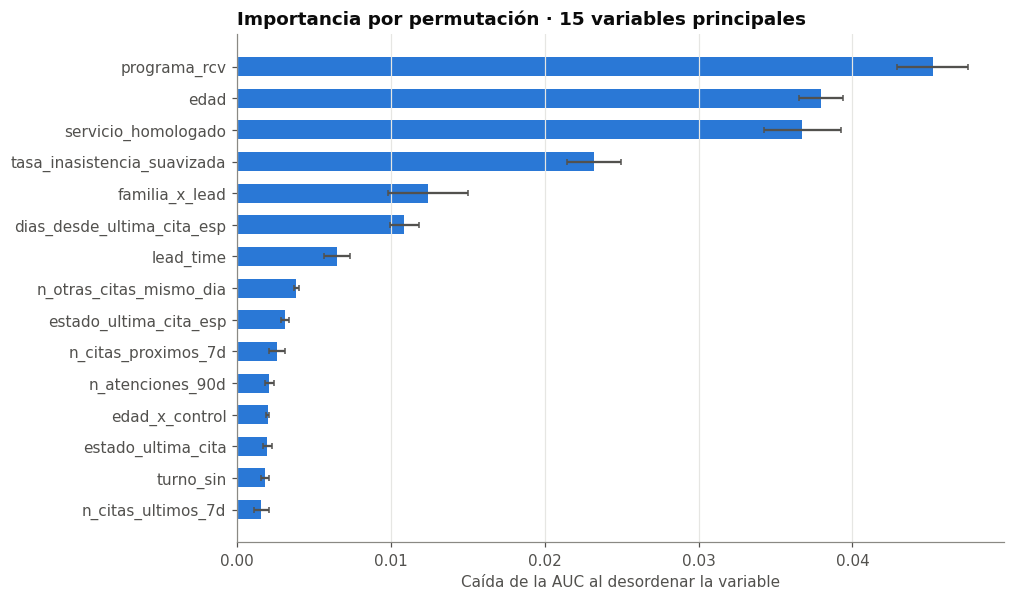

In [10]:
modelo_validacion = entrenar(train)
muestra = validacion.sample(20_000, random_state=42)
importancia = permutation_importance(modelo_validacion, muestra[variables], muestra["no_asiste"],
                                     scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=1)
tabla_importancia = pd.DataFrame({"variable": variables, "caida_AUC": importancia.importances_mean,
                                  "desv": importancia.importances_std}).sort_values("caida_AUC", ascending=False)

top15 = tabla_importancia.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15["variable"], top15["caida_AUC"], xerr=top15["desv"], color=fm.AZUL, height=0.6,
        error_kw={"ecolor": fm.TINTA_SUAVE, "capsize": 2})
ax.invert_yaxis()
ax.set_xlabel("Caída de la AUC al desordenar la variable")
ax.set_title("Importancia por permutación · 15 variables principales")
ax.grid(axis="y", visible=False)
plt.show()

## 7.2 Dependencia parcial
**Pregunta:** si cambio **solo** esta variable y dejo todo lo demás igual, ¿cómo cambia la probabilidad de inasistencia en promedio?

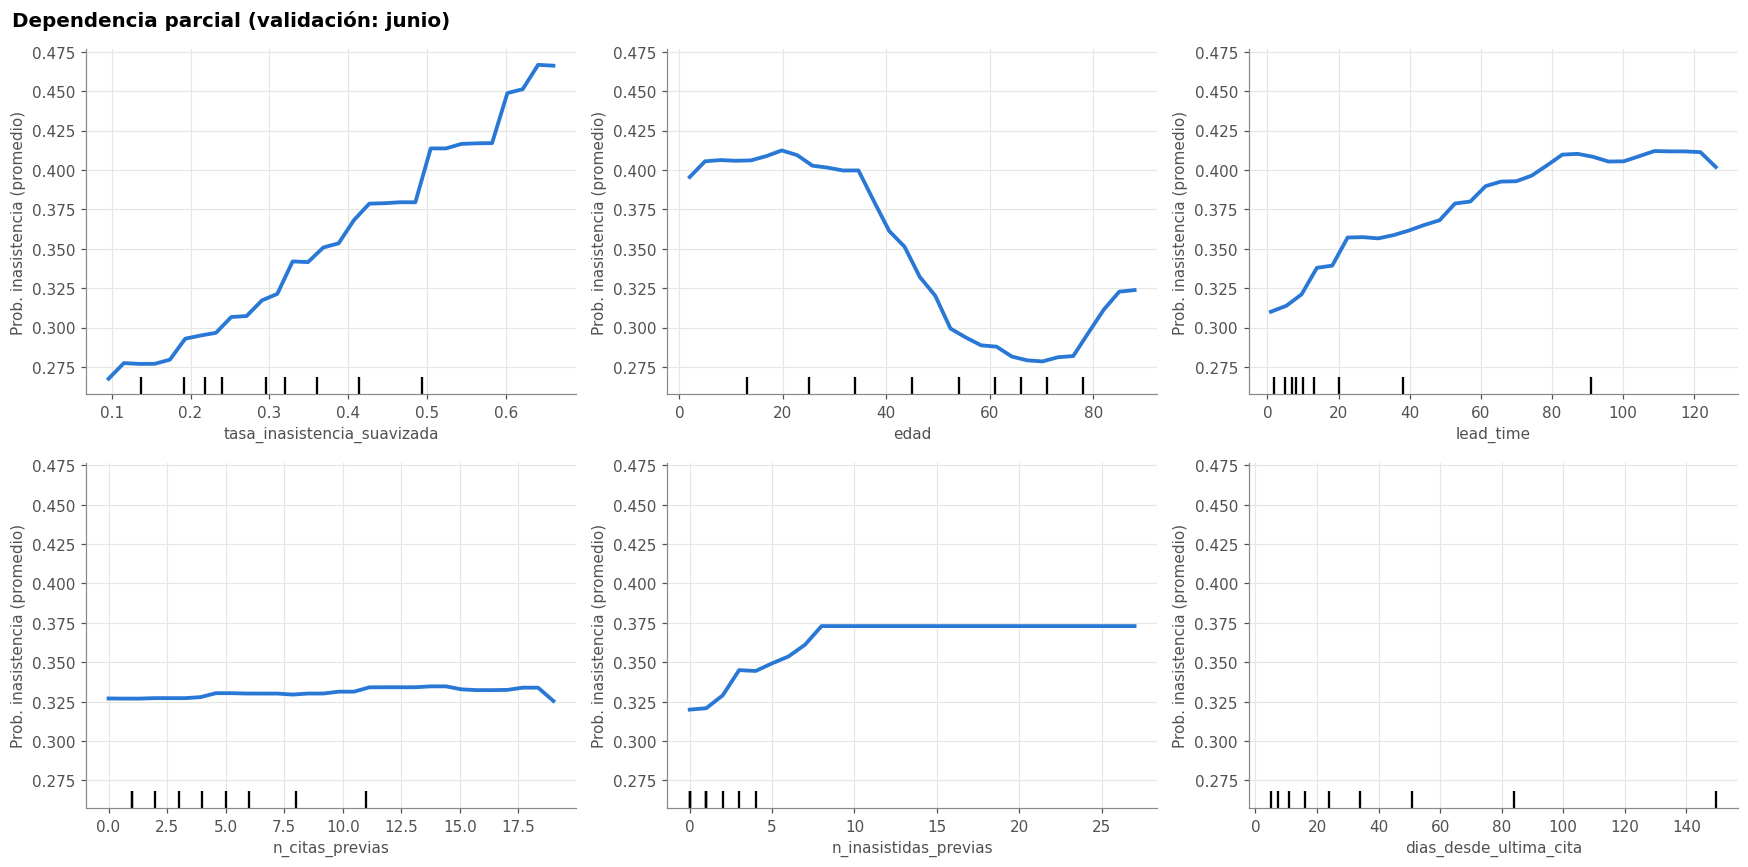

In [11]:
variables_pdp = [v for v in ["tasa_inasistencia_suavizada", "edad", "lead_time", "n_citas_previas", "n_inasistidas_previas", "dias_desde_ultima_cita"]
                 if v in variables]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    modelo_validacion, muestra[variables].sample(5_000, random_state=1), variables_pdp, ax=axes.ravel()[:len(variables_pdp)],
    kind="average", grid_resolution=30, percentiles=(0.02, 0.98),
    line_kw={"color": fm.AZUL, "linewidth": 2.5},
)
for ax in axes.ravel():
    ax.set_ylabel("Prob. inasistencia (promedio)")
fig.suptitle("Dependencia parcial (validación: junio)", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7.3 Coeficientes de la regresión logística: explicación "de negocio"
La logística es menos precisa, pero **fácil de explicar**. Su coeficiente convertido en *odds ratio* ($e^{\beta}$) dice cuánto se multiplican las "chances" de faltar:
- **OR > 1:** aumenta el riesgo (por ejemplo, 1,30 = 30 % más chances).
- **OR < 1:** lo reduce.

Para las variables numéricas (estandarizadas), el OR corresponde a **una desviación estándar** de aumento.

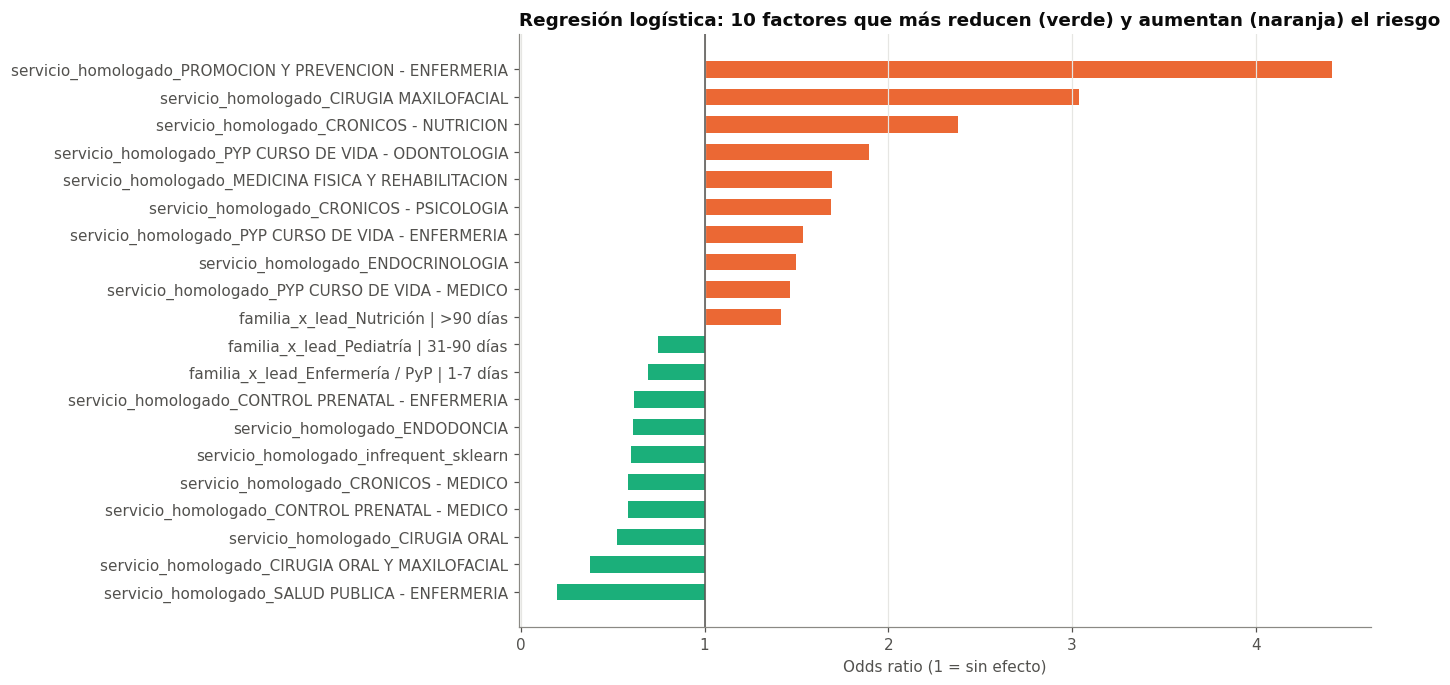

In [12]:
params_log = mejores_parametros.get("logistica", {"C": 0.1})
logistica = fm.crear_modelo("logistica", categoricas, numericas, **params_log)
logistica.fit(desarrollo[variables], desarrollo["no_asiste"])
nombres = logistica.named_steps["prep"].get_feature_names_out()
coeficientes = pd.DataFrame({"variable": nombres, "coeficiente": logistica.named_steps["clf"].coef_[0]})
coeficientes["variable"] = coeficientes["variable"].str.replace("num__", "").str.replace("cat__", "")
coeficientes["odds_ratio"] = np.exp(coeficientes["coeficiente"])
coeficientes = coeficientes.sort_values("coeficiente")

extremos = pd.concat([coeficientes.head(10), coeficientes.tail(10)])
fig, ax = plt.subplots(figsize=(10, 7))
colores = [fm.AQUA if c < 0 else fm.NARANJA for c in extremos["coeficiente"]]
ax.barh(extremos["variable"], extremos["odds_ratio"] - 1, left=1, color=colores, height=0.6)
ax.axvline(1, color=fm.TINTA_SUAVE, linewidth=1)
ax.set_xlabel("Odds ratio (1 = sin efecto)")
ax.set_title("Regresión logística: 10 factores que más reducen (verde) y aumentan (naranja) el riesgo")
ax.grid(axis="y", visible=False)
plt.show()

## Las 10 variables que más influyen, en lenguaje sencillo (entregable Fase 7)

In [13]:
explicaciones = {
    "tasa_inasistencia_suavizada": "Qué tanto ha faltado el paciente en el pasado. Es el mejor predictor: quien falta, tiende a volver a faltar.",
    "edad": "Los jóvenes (12-28 años) faltan mucho más que los adultos mayores, que son los más cumplidos.",
    "servicio_homologado": "Cada servicio tiene su propia tasa: salud mental y nutrición tienen más inasistencia; medicina general y crónicos, menos.",
    "especialidad": "Especialidad de la cita.",
    "familia_servicio": "Agrupa las especialidades: salud mental y nutrición son las de mayor riesgo.",
    "lead_time": "Cuántos días pasaron entre pedir la cita y la cita. Mientras más lejos, más fácil que el paciente la olvide o resuelva por otro lado.",
    "programa_rcv": "Los pacientes de programas crónicos (hipertensión, diabetes, nefroprotección) son más cumplidos: tienen un vínculo con la IPS.",
    "n_citas_previas": "Cuántas citas ha tenido el paciente: los que usan mucho el servicio suelen ser más cumplidos.",
    "n_inasistidas_previas": "Cuántas veces ha faltado antes, en total.",
    "estado_ultima_cita": "Si faltó a su última cita, el riesgo sube.",
    "dias_desde_ultima_cita": "Cuánto tiempo pasó desde su última cita: los pacientes frecuentes son más cumplidos.",
    "tipo_usuario": "Los beneficiarios faltan más que los cotizantes.",
    "tasa_inasistencia_suavizada_esp": "Qué tanto ha faltado el paciente EN ESTA especialidad.",
    "n_inasistidas_previas_esp": "Cuántas veces ha faltado a esta misma especialidad.",
    "n_citas_previas_esp": "Cuántas citas ha tenido en esta especialidad.",
    "dias_desde_ultima_cita_esp": "Tiempo desde la última cita de esta especialidad.",
    "estado_ultima_cita_esp": "Si faltó a la última cita de esta especialidad.",
    "n_otras_citas_mismo_dia": "Si tiene otras citas el mismo día: quien viene a varias citas juntas suele asistir.",
    "n_citas_proximos_7d": "Otras citas agendadas en la semana siguiente.",
    "n_citas_ultimos_7d": "Citas en la semana anterior: alguien en tratamiento activo.",
    "familia_x_lead": "Combinación servicio × tiempo de espera: el efecto de esperar depende del servicio.",
    "edad_x_control": "Combinación curso de vida × primera vez/control.",
    "grupo_edad": "Curso de vida del paciente.",
    "n_diagnosticos_previos": "Cantidad de diagnósticos registrados: pacientes con más condiciones suelen ser más cumplidos.",
    "n_atenciones_90d": "Cuántas veces fue atendido en los últimos 90 días (uso reciente del servicio).",
    "n_medicamentos_90d": "Medicamentos formulados recientemente.",
    "sede": "Sede de la cita.",
    "dia_semana": "Día de la semana (efecto pequeño e inestable).",
    "turno_sin": "Hora de la cita (codificación cíclica).",
    "turno_cos": "Hora de la cita (codificación cíclica).",
    "franja_horaria": "Franja horaria de la cita.",
    "es_control": "Primera vez vs. control.",
    "sin_historial": "Primera cita del paciente en el periodo: el riesgo se estima solo por su perfil.",
    "semana_mes": "Semana del mes.",
    "dias_hasta_festivo": "Cercanía a un festivo.",
    "lead_time_cat": "Tiempo de espera en rangos.",
    "sexo": "Sexo del paciente (efecto pequeño).",
    "regimen": "Régimen contributivo o subsidiado.",
    "nivel_usr": "Nivel del usuario.",
    "diabetes": "Paciente con diabetes (más cumplido).",
    "gestante_activa": "Gestante en la fecha de la cita.",
}
top10 = tabla_importancia.head(10).copy()
top10["explicacion"] = top10["variable"].map(explicaciones).fillna("")
top10["caida_AUC"] = top10["caida_AUC"].round(4)
top10[["variable", "caida_AUC", "explicacion"]].style.set_properties(**{"text-align": "left", "white-space": "normal"})

,variable,caida_AUC,explicacion
29,programa_rcv,0.045200,"Los pacientes de programas crónicos (hipertensión, diabetes, nefroprotección) son más cumplidos: tienen un vínculo con la IPS."
8,edad,0.037900,"Los jóvenes (12-28 años) faltan mucho más que los adultos mayores, que son los más cumplidos."
6,servicio_homologado,0.036700,"Cada servicio tiene su propia tasa: salud mental y nutrición tienen más inasistencia; medicina general y crónicos, menos."
25,tasa_inasistencia_suavizada,0.023200,"Qué tanto ha faltado el paciente en el pasado. Es el mejor predictor: quien falta, tiende a volver a faltar."
43,familia_x_lead,0.012400,Combinación servicio × tiempo de espera: el efecto de esperar depende del servicio.
39,dias_desde_ultima_cita_esp,0.010900,Tiempo desde la última cita de esta especialidad.
0,lead_time,0.006500,"Cuántos días pasaron entre pedir la cita y la cita. Mientras más lejos, más fácil que el paciente la olvide o resuelva por otro lado."
40,n_otras_citas_mismo_dia,0.003800,Si tiene otras citas el mismo día: quien viene a varias citas juntas suele asistir.
38,estado_ultima_cita_esp,0.003100,Si faltó a la última cita de esta especialidad.
41,n_citas_proximos_7d,0.002600,Otras citas agendadas en la semana siguiente.


# Fase 8 · Herramienta predictiva

## 8.1 Modelo de producción
Ya evaluado el test, el modelo de producción se **re-entrena con todos los datos etiquetados hasta julio**: más datos, y más recientes. Se guarda junto con todo lo necesario para usarlo (variables, versión, parámetros, mapa de servicios y especialidades excluidas).

In [14]:
hasta_julio = dataset[dataset["particion"].isin(["train", "validacion", "test"])]
if config["calibrar"]:
    modelo_produccion = entrenar(hasta_julio[hasta_julio["fecha_cita"] < "2026-07-01"], test)
else:
    modelo_produccion = entrenar(hasta_julio)

params_produccion = dict(fi.PARAMETROS)
params_produccion["PRIOR_INASISTENCIA"] = metadatos["PRIOR_INASISTENCIA"]
version = f"1.0-{pd.Timestamp.today():%Y%m%d}"
paquete = {
    "modelo": modelo_produccion,
    "variables": variables,
    "version": version,
    "nombre_modelo": config["nombre"],
    "parametros_modelo": parametros,
    "entrenado_hasta": str(hasta_julio["fecha_cita"].max().date()),
    "parametros": params_produccion,
    "mapa_servicio": metadatos["mapa_servicio"],
    "especialidades_excluidas": metadatos["especialidades_excluidas"],
    "codigos_descontinuados": metadatos["codigos_descontinuados"],
    "metricas_test": metricas_test,
}
Path("modelos").mkdir(exist_ok=True)
joblib.dump(paquete, "modelos/modelo_inasistencia.joblib")
print(f"Guardado modelos/modelo_inasistencia.joblib | versión {version} | entrenado hasta {paquete['entrenado_hasta']}")

Guardado modelos/modelo_inasistencia.joblib | versión 1.0-20260927 | entrenado hasta 2026-07-31


## 8.2 Ejemplo de la herramienta diaria
`prediccion_diaria.py` recibe una fecha y, usando **solo la información disponible el día anterior**, genera el Excel priorizado. Como agosto ya pasó, podemos comparar la predicción con lo que realmente ocurrió.

Desde la terminal se usa así:
```
python prediccion_diaria.py --fecha 2026-08-27 --evaluar
```

In [15]:
import prediccion_diaria as pdiaria

fuentes = fi.cargar_fuentes(".")
fecha_ejemplo = "2026-08-27"
evaluadas, no_evaluadas = pdiaria.predecir_citas(fecha_ejemplo, ".", paquete, fuentes)
ruta = pdiaria.guardar_excel(evaluadas, no_evaluadas, fecha_ejemplo, "salidas")
print(f"Archivo: {ruta} | evaluadas: {len(evaluadas)} | no evaluadas: {len(no_evaluadas)}")

evaluadas[["prioridad", "nivel_riesgo", "probabilidad_inasistencia", "hora_cita", "especialidad", "sede", "edad", "motivos"]].head(15).round(3)

Archivo: salidas/prediccion_2026-08-27.xlsx | evaluadas: 1834 | no evaluadas: 358


,prioridad,nivel_riesgo,probabilidad_inasistencia,hora_cita,especialidad,sede,edad,motivos
667,1,Alto,0.895,17,NUTRICIONISTA,LAURELES,86,Servicio con alta inasistencia (Nutrición)
1665,2,Alto,0.874,18,MEDICINA GENERAL,CENTRO,6,"Falta con frecuencia (9 de 16); Niño, adolesce..."
555,3,Alto,0.854,11,NUTRICIONISTA,ARMENIA,35,Faltó a su última cita; Falta con frecuencia (...
460,4,Alto,0.849,7,ODONTOLOGIA,LAURELES,30,Faltó a su última cita; Falta con frecuencia (...
526,5,Alto,0.844,10,ODONTOLOGIA,ARMENIA,31,Falta con frecuencia (11 de 12); Faltó a la úl...
46,6,Alto,0.841,7,MEDICINA GENERAL,VILLAMARIA,26,"Niño, adolescente o joven (grupos con más inas..."
839,7,Alto,0.840,10,ODONTOLOGIA,VILLAMARIA,47,No pertenece a un programa de crónicos
1807,8,Alto,0.830,9,PROMOCION Y PREVENCION - ENFERMERIA,VILLAMARIA,9,"Niño, adolescente o joven (grupos con más inas..."
29,9,Alto,0.817,8,MEDICINA GENERAL,CENTRO,25,Faltó a su última cita; Falta con frecuencia (...
439,10,Alto,0.815,14,NUTRICIONISTA,CENTRO,28,Faltó a su última cita; Falta con frecuencia (...


In [16]:
real, resumen_real = pdiaria.evaluar_contra_realidad(evaluadas, fuentes, paquete)
print(f"Inasistencia real del día: {real['no_asiste'].mean():.1%}")
resumen_real.round(3)

Inasistencia real del día: 35.1%


,citas,inasistencia_real
nivel_riesgo,,
Alto,183,0.705
Medio,367,0.433
Bajo,1284,0.276


> **Nota sobre el ejemplo:** se eligió el 27 de agosto porque ese día RIPS reportó con normalidad. En días con fallas de reporte (por ejemplo, Armenia del 2 al 11 de septiembre) la comparación con la "realidad" no sería válida.

## 8.3 Interfaz (opcional)
`app_streamlit.py` ofrece la misma herramienta con una interfaz web sencilla. Se ejecuta con:
```
streamlit run app_streamlit.py
```

## 8.4 Plan de monitoreo: simulación en agosto–septiembre
Aplicamos el modelo de producción (entrenado hasta julio) a agosto y septiembre, **como si estuviera en operación**, y revisamos mes a mes:
1. **Tasa real vs. tasa predicha:** si se separan más de 3 pp → **recalibrar**.
2. **AUC mensual:** si cae más de 0,03 frente al test → **reentrenar**.

In [17]:
produccion = dataset[dataset["particion"] == "produccion_simulada"].copy()
produccion["p"] = modelo_produccion.predict_proba(produccion[variables])[:, 1]
produccion["mes"] = produccion["fecha_cita"].dt.to_period("M").astype(str)

referencia = test.assign(p=p_test, mes="2026-07 (test)")
monitoreo = pd.concat([referencia, produccion])
filas = []
for mes, datos in monitoreo.groupby("mes"):
    m = fm.metricas(datos["no_asiste"], datos["p"], datos["fecha_cita"])
    filas.append({"mes": mes, "citas": len(datos), "tasa_real": datos["no_asiste"].mean(), "tasa_predicha": datos["p"].mean(),
                  "AUC": m["AUC"], "Precision@10%": m["Precision@10%"], "Recall@10%": m["Recall@10%"]})
tabla_monitoreo = pd.DataFrame(filas)
tabla_monitoreo["brecha_pp"] = (tabla_monitoreo["tasa_predicha"] - tabla_monitoreo["tasa_real"]) * 100
tabla_monitoreo["caida_AUC_vs_test"] = metricas_test["AUC"] - tabla_monitoreo["AUC"]

def estado(fila):
    alertas = []
    if abs(fila["brecha_pp"]) > 3:
        alertas.append("RECALIBRAR")
    if fila["caida_AUC_vs_test"] > 0.03:
        alertas.append("REENTRENAR")
    return " + ".join(alertas) if alertas else "OK"

tabla_monitoreo["estado"] = tabla_monitoreo.apply(estado, axis=1)
tabla_monitoreo.round(3)

,mes,citas,tasa_real,tasa_predicha,AUC,Precision@10%,Recall@10%,brecha_pp,caida_AUC_vs_test,estado
0,2026-07 (test),41148,0.312,0.323,0.682,0.575,0.184,1.046,0.000,OK
1,2026-08,30350,0.316,0.306,0.692,0.609,0.192,-0.967,-0.010,OK
2,2026-09,15756,0.288,0.296,0.694,0.575,0.199,0.829,-0.012,OK


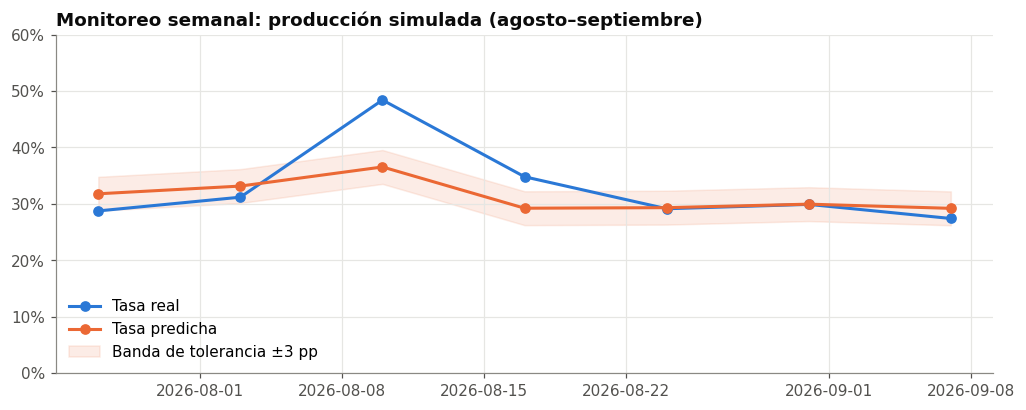

In [18]:
produccion["semana"] = produccion["fecha_cita"].dt.to_period("W-SUN").dt.start_time
semanal = produccion.groupby("semana").agg(real=("no_asiste", "mean"), predicha=("p", "mean"))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(semanal.index, semanal["real"], color=fm.AZUL, linewidth=2, marker="o", markersize=6, label="Tasa real")
ax.plot(semanal.index, semanal["predicha"], color=fm.NARANJA, linewidth=2, marker="o", markersize=6, label="Tasa predicha")
ax.fill_between(semanal.index, semanal["predicha"] - 0.03, semanal["predicha"] + 0.03, color=fm.NARANJA, alpha=0.12,
                label="Banda de tolerancia ±3 pp")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, 0.6)
ax.set_title("Monitoreo semanal: producción simulada (agosto–septiembre)")
ax.legend(loc="lower left")
plt.show()

**Protocolo de monitoreo recomendado**

| Frecuencia | Qué revisar | Umbral | Acción |
|---|---|---|---|
| Semanal | Tasa real vs. predicha | Brecha > 3 pp durante 2 semanas seguidas | Revisar primero si RIPS reportó bien (fallas como las del notebook 01); si los datos están bien, recalibrar |
| Mensual | AUC y precisión@10 % | Caída de la AUC > 0,03 vs. test | Reentrenar con los últimos meses |
| Mensual | Desempeño por subgrupo (6.3) | Brecha de calibración > 5 pp en un grupo | Analizar el grupo; considerar variables nuevas |
| Mensual | Especialidades con tendencia (p. ej., dermatología) | Cambio de tasa > 10 pp | Verificar si cambió el registro o el servicio |
| Mensual | Reentrenamiento programado | — | Reentrenar con todos los meses etiquetados (ventana creciente) |

> Antes de reentrenar hay que correr de nuevo `01_Auditoria_Etiqueta` sobre los meses nuevos. Una falla de reporte en RIPS **parece** caída del modelo, pero es un problema de datos.